In [353]:
# Install UCI dataset package
!pip install -q ucimlrepo

In [354]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [355]:
import sklearn
print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.6.1


In [356]:
# Fetch Breast Cancer Wisconsin Diagnostic dataset from UCI
dataset = fetch_ucirepo(id=17)

# Features
X = dataset.data.features.copy()

# Target
y = dataset.data.targets.copy()

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully!
Features shape: (569, 30)
Target shape: (569, 1)


In [357]:
print("First 5 rows:")
display(X.head())

print("\nDataset information:")
X.info()

print("\nTarget values:")
print(y.head())

print("\nTarget distribution:")
print(y.value_counts())

First 5 rows:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null   

In [358]:
# Convert target to a single Series
y = y.iloc[:, 0]

# Convert diagnosis:
# B = Benign = 0
# M = Malignant = 1
y = y.map({"B": 0, "M": 1})

print("Target values after encoding:")
print(y.value_counts())

print("\nUnique target values:")
print(y.unique())

Target values after encoding:
Diagnosis
0    357
1    212
Name: count, dtype: int64

Unique target values:
[1 0]


In [359]:
print("Missing values in features:")
print(X.isnull().sum().sum())

print("Missing values in target:")
print(y.isnull().sum())

Missing values in features:
0
Missing values in target:
0


In [360]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


Feature Scaling of the Model

Scaling is especially important for:
Logistic Regression
, kNN

In [361]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Feature scaling completed.
Scaled training shape: (455, 30)
Scaled testing shape: (114, 30)


In [362]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "kNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

print("Models created:")
for name in models:
    print("-", name)

Models created:
- Logistic Regression
- Decision Tree
- kNN
- Naive Bayes
- Random Forest


Training all models

In [363]:
trained_models = {}

for name, model in models.items():

    if name in ["Logistic Regression", "kNN"]:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    trained_models[name] = model

print("All models trained successfully.")

All models trained successfully.


Calculating all required metrics:

1.Accuracy

2.AUC

3.Precision

4.Recall

5.F1

6.MCC

In [364]:
results = []

for name, model in trained_models.items():

    # Use scaled data for Logistic Regression and kNN
    if name in ["Logistic Regression", "kNN"]:
        X_eval = X_test_scaled
    else:
        X_eval = X_test

    # Predictions
    y_pred = model.predict(X_eval)

    # Probability for AUC
    y_prob = model.predict_proba(X_eval)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        "ML Model": name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc
    })

results_df = pd.DataFrame(results)

print("Evaluation completed.")
display(results_df)

Evaluation completed.


,ML Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.964912,0.996032,0.975000,0.928571,0.951220,0.924518
1,Decision Tree,0.929825,0.924603,0.904762,0.904762,0.904762,0.849206
2,kNN,0.956140,0.982308,0.974359,0.904762,0.938272,0.905824
3,Naive Bayes,0.938596,0.993386,1.000000,0.833333,0.909091,0.871489
4,Random Forest,0.964912,0.994213,1.000000,0.904762,0.950000,0.925820


In [365]:
results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]

results_display[metric_columns] = results_display[metric_columns].round(4)

display(results_display)

,ML Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9649,0.9960,0.9750,0.9286,0.9512,0.9245
1,Decision Tree,0.9298,0.9246,0.9048,0.9048,0.9048,0.8492
2,kNN,0.9561,0.9823,0.9744,0.9048,0.9383,0.9058
3,Naive Bayes,0.9386,0.9934,1.0000,0.8333,0.9091,0.8715
4,Random Forest,0.9649,0.9942,1.0000,0.9048,0.9500,0.9258


In [366]:
# Calculate average of all six metrics
results_df["Average Score"] = results_df[
    ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]
].mean(axis=1)

winner = results_df.loc[
    results_df["Average Score"].idxmax(),
    "ML Model"
]

print("Overall Winner:", winner)

display(
    results_df.sort_values(
        "Average Score",
        ascending=False
    )
)

Overall Winner: Logistic Regression


,ML Model,Accuracy,AUC,Precision,Recall,F1,MCC,Average Score
0,Logistic Regression,0.964912,0.996032,0.975000,0.928571,0.951220,0.924518,0.956709
4,Random Forest,0.964912,0.994213,1.000000,0.904762,0.950000,0.925820,0.956618
2,kNN,0.956140,0.982308,0.974359,0.904762,0.938272,0.905824,0.943611
3,Naive Bayes,0.938596,0.993386,1.000000,0.833333,0.909091,0.871489,0.924316
1,Decision Tree,0.929825,0.924603,0.904762,0.904762,0.904762,0.849206,0.902987


### Visualizing Overall Model Performance

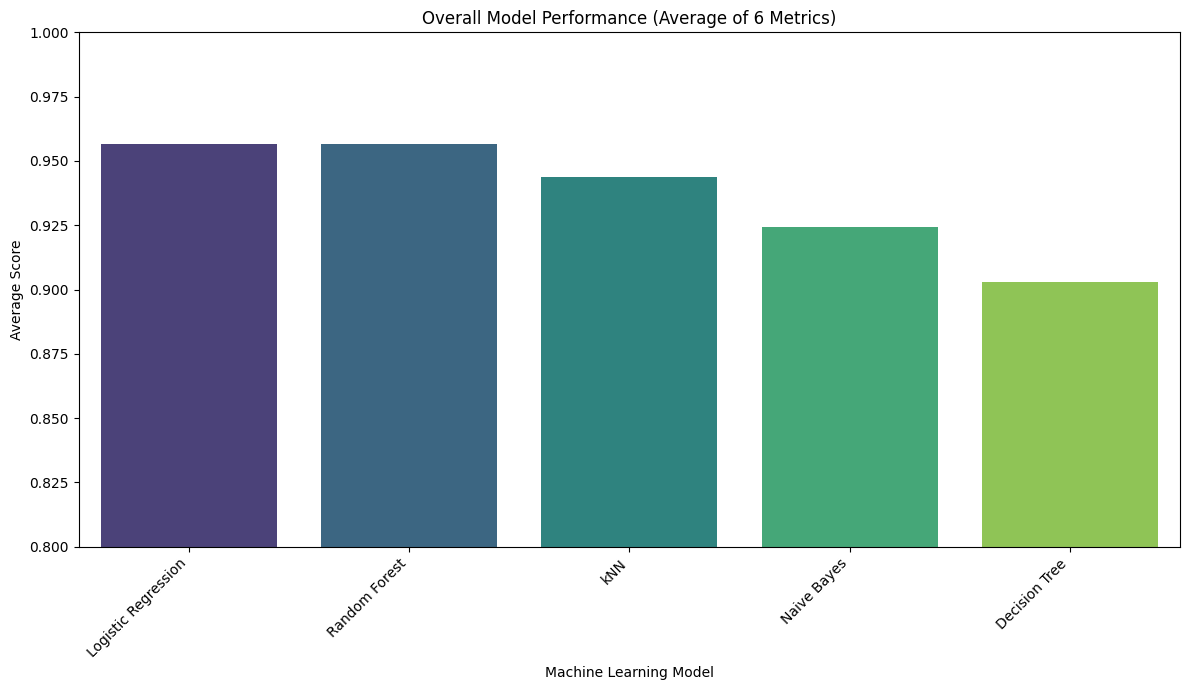

In [367]:
plt.figure(figsize=(12, 7))
sns.barplot(x='ML Model', y='Average Score', data=results_df.sort_values(by='Average Score', ascending=False), palette='viridis')
plt.title('Overall Model Performance (Average of 6 Metrics)')
plt.xlabel('Machine Learning Model')
plt.ylabel('Average Score')
plt.ylim(0.8, 1.0) # Set y-limit for better comparison
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Confusion matrix

In [368]:
for name, model in trained_models.items():

    if name in ["Logistic Regression", "kNN"]:
        X_eval = X_test_scaled
    else:
        X_eval = X_test

    y_pred = model.predict(X_eval)

    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(cm)


Logistic Regression
[[71  1]
 [ 3 39]]

Decision Tree
[[68  4]
 [ 4 38]]

kNN
[[71  1]
 [ 4 38]]

Naive Bayes
[[72  0]
 [ 7 35]]

Random Forest
[[72  0]
 [ 4 38]]


Classification reports

In [369]:
for name, model in trained_models.items():

    if name in ["Logistic Regression", "kNN"]:
        X_eval = X_test_scaled
    else:
        X_eval = X_test

    y_pred = model.predict(X_eval)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Benign", "Malignant"]
        )
    )


Logistic Regression
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Decision Tree
              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94        72
   Malignant       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114


kNN
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96

Creating a proper confusion matrix plot

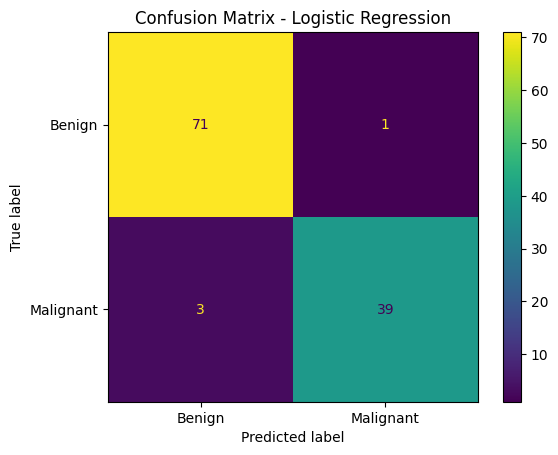

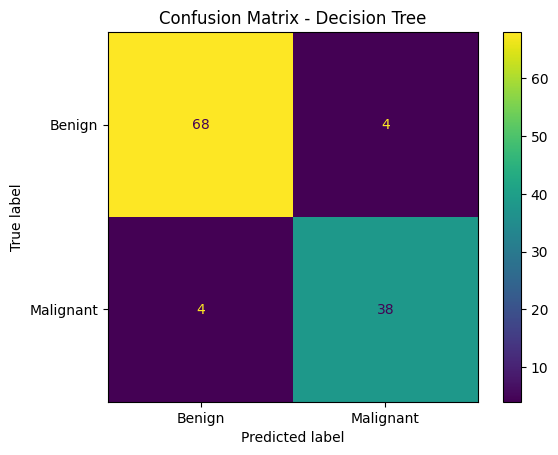

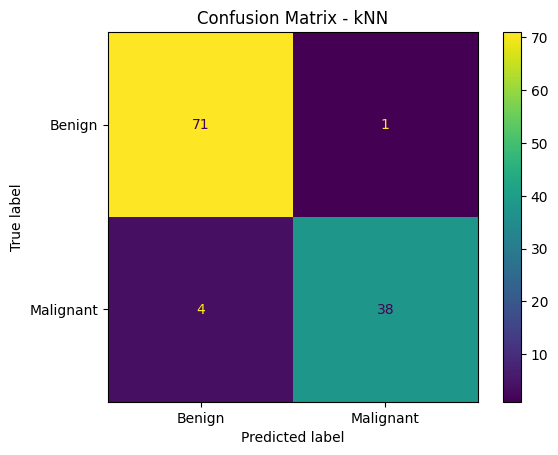

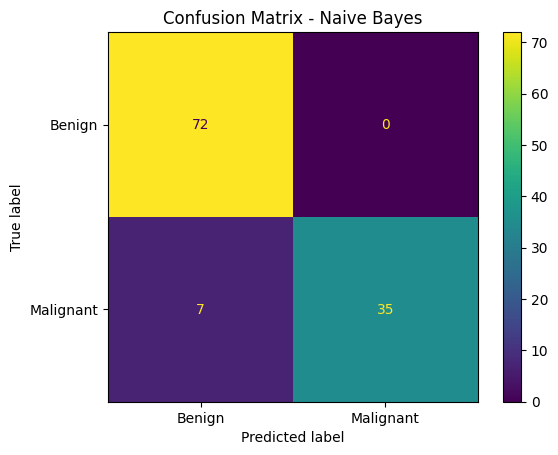

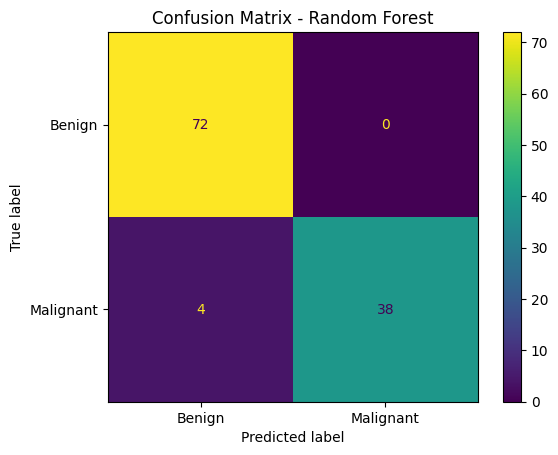

In [370]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in trained_models.items():

    if name in ["Logistic Regression", "kNN"]:
        X_eval = X_test_scaled
    else:
        X_eval = X_test

    y_pred = model.predict(X_eval)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Benign", "Malignant"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

Creating test_data.csv

In [371]:
# Create test dataset with target column
test_data = X_test.copy()

test_data["Diagnosis"] = y_test.values

# Save to CSV
test_data.to_csv(
    "test_data.csv",
    index=False
)

print("test_data.csv created successfully.")

print("Shape:", test_data.shape)

display(test_data.head())

test_data.csv created successfully.
Shape: (114, 31)


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
120,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,...,15.97,83.74,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523,0
250,20.94,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,...,27.00,165.30,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849,1
375,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,...,19.14,113.10,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960,0
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,...,30.86,109.50,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353,1
455,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,...,41.61,96.69,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675,0


In [372]:
import os
import joblib

os.makedirs("model", exist_ok=True)

for name, model in trained_models.items():

    filename = name.lower().replace(" ", "_").replace("-", "_")

    joblib.dump(
        model,
        f"model/{filename}.pkl"
    )

print("All models saved.")

All models saved.


In [373]:
joblib.dump(
    scaler,
    "model/scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


Creating the Streamlit app

In [374]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Breast Cancer Classification",
    page_icon="📊",
    layout="wide"
)


# ============================================================
# APPLICATION TITLE
# ============================================================

st.title("📊 Breast Cancer Classification Dashboard")

st.markdown(
    """
    This application evaluates multiple machine learning
    classification models using the Breast Cancer Wisconsin
    Diagnostic dataset.
    """
)

st.info(
    "Upload the test CSV file and select a machine learning model "
    "to view its classification performance."
)


# ============================================================
# LOAD TRAINED MODELS
# ============================================================

@st.cache_resource
def load_models():

    models = {
        "Logistic Regression":
            joblib.load("model/logistic_regression.pkl"),

        "Decision Tree":
            joblib.load("model/decision_tree.pkl"),

        "kNN":
            joblib.load("model/knn.pkl"),

        "Naive Bayes":
            joblib.load("model/naive_bayes.pkl"),

        "Random Forest":
            joblib.load("model/random_forest.pkl")
    }

    scaler = joblib.load("model/scaler.pkl")

    return models, scaler


# ============================================================
# LOAD MODELS SAFELY
# ============================================================

try:

    models, scaler = load_models()

except Exception as e:

    st.error(
        "Unable to load the trained model files."
    )

    st.code(str(e))

    st.stop()


# ============================================================
# MODEL SELECTION
# ============================================================

st.subheader("1. Select Machine Learning Model")

selected_model_name = st.selectbox(
    "Choose a model:",
    list(models.keys())
)

selected_model = models[selected_model_name]


# ============================================================
# FILE UPLOAD
# ============================================================

st.subheader("2. Upload Test Data")

uploaded_file = st.file_uploader(
    "Upload test_data.csv",
    type=["csv"]
)


# ============================================================
# MAIN PROCESSING
# ============================================================

if uploaded_file is None:

    st.warning(
        "Please upload the test_data.csv file to evaluate the model."
    )

    st.stop()


# ============================================================
# READ CSV
# ============================================================

try:

    data = pd.read_csv(uploaded_file)

except Exception as e:

    st.error("Unable to read the uploaded CSV file.")

    st.code(str(e))

    st.stop()


# ============================================================
# DISPLAY UPLOADED DATA
# ============================================================

st.subheader("3. Uploaded Test Data")

st.write(
    f"Dataset contains **{data.shape[0]} rows** "
    f"and **{data.shape[1]} columns**."
)

st.dataframe(
    data.head(10),
    use_container_width=True
)


# ============================================================
# CHECK TARGET COLUMN
# ============================================================

target_column = "Diagnosis"

if target_column not in data.columns:

    st.error(
        "The uploaded CSV must contain a 'Diagnosis' target column."
    )

    st.write("Columns found in uploaded file:")

    st.write(
        list(data.columns)
    )

    st.stop()


# ============================================================
# IDENTIFY EXPECTED FEATURE COLUMNS
# ============================================================

try:

    expected_features = list(
        scaler.feature_names_in_
    )

except AttributeError:

    expected_features = [
        column
        for column in data.columns
        if column != target_column
    ]


# ============================================================
# CHECK FEATURE COLUMNS
# ============================================================

uploaded_features = [
    column
    for column in data.columns
    if column != target_column
]


missing_features = [
    feature
    for feature in expected_features
    if feature not in uploaded_features
]


extra_features = [
    feature
    for feature in uploaded_features
    if feature not in expected_features
]


if missing_features:

    st.error(
        "The uploaded CSV is missing required feature columns."
    )

    st.write(
        "Missing columns:"
    )

    st.write(missing_features)

    st.stop()


if extra_features:

    st.warning(
        "The uploaded CSV contains additional columns. "
        "Only the trained model features will be used."
    )


# ============================================================
# SELECT FEATURES IN EXACT TRAINING ORDER
# ============================================================

X = data[expected_features].copy()

y = data[target_column].copy()


# ============================================================
# CONVERT FEATURES TO NUMERIC
# ============================================================

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)


# ============================================================
# CHECK MISSING FEATURE VALUES
# ============================================================

missing_value_count = X.isnull().sum().sum()

if missing_value_count > 0:
    st.error(
        "The uploaded test data contains missing feature values. "
        "Please upload the original test_data.csv without missing values."
    )
    st.stop()

# ============================================================
# CONVERT TARGET
# ============================================================

if y.dtype == "object":

    y = y.map(
        {
            "B": 0,
            "M": 1,
            "Benign": 0,
            "Malignant": 1
        }
    )


# ============================================================
# CHECK TARGET VALUES
# ============================================================

if y.isnull().any():

    st.error(
        "The Diagnosis column contains unsupported target values."
    )

    st.write(
        "Expected values: B/M or Benign/Malignant"
    )

    st.stop()


y = y.astype(int)


# ============================================================
# PREPARE INPUT DATA
# ============================================================

if selected_model_name in [
    "Logistic Regression",
    "kNN"
]:

    X_input = scaler.transform(X)

else:

    X_input = X


# ============================================================
# MAKE PREDICTIONS
# ============================================================

try:

    y_pred = selected_model.predict(
        X_input
    )

    y_prob = selected_model.predict_proba(
        X_input
    )[:, 1]

except Exception as e:

    st.error(
        "An error occurred while generating predictions."
    )

    st.code(str(e))

    st.stop()


# ============================================================
# CALCULATE METRICS
# ============================================================

accuracy = accuracy_score(
    y,
    y_pred
)

precision = precision_score(
    y,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y,
    y_pred,
    zero_division=0
)

mcc = matthews_corrcoef(
    y,
    y_pred
)


# ============================================================
# AUC
# ============================================================

try:

    auc = roc_auc_score(
        y,
        y_prob
    )

    auc_display = f"{auc:.4f}"

except ValueError:

    auc = None

    auc_display = "N/A"


# ============================================================
# DISPLAY MODEL NAME
# ============================================================

st.divider()

st.subheader(
    f"4. Evaluation Results — {selected_model_name}"
)


# ============================================================
# DISPLAY METRICS
# ============================================================

col1, col2, col3 = st.columns(3)

with col1:

    st.metric(
        "Accuracy",
        f"{accuracy:.4f}"
    )

with col2:

    st.metric(
        "AUC",
        auc_display
    )

with col3:

    st.metric(
        "Precision",
        f"{precision:.4f}"
    )


col4, col5, col6 = st.columns(3)

with col4:

    st.metric(
        "Recall",
        f"{recall:.4f}"
    )

with col5:

    st.metric(
        "F1 Score",
        f"{f1:.4f}"
    )

with col6:

    st.metric(
        "MCC",
        f"{mcc:.4f}"
    )


# ============================================================
# CONFUSION MATRIX
# ============================================================

st.subheader("5. Confusion Matrix")

cm = confusion_matrix(
    y,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Benign",
        "Actual Malignant"
    ],
    columns=[
        "Predicted Benign",
        "Predicted Malignant"
    ]
)

st.dataframe(
    cm_df,
    use_container_width=True
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

st.subheader("6. Classification Report")

report = classification_report(
    y,
    y_pred,
    target_names=[
        "Benign",
        "Malignant"
    ],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report
).transpose()

st.dataframe(
    report_df.round(4),
    use_container_width=True
)


# ============================================================
# PREDICTION RESULTS
# ============================================================

st.subheader("7. Prediction Results")

prediction_data = data.copy()

prediction_data[
    "Predicted Diagnosis"
] = np.where(
    y_pred == 1,
    "Malignant",
    "Benign"
)

st.dataframe(
    prediction_data,
    use_container_width=True
)

Overwriting app.py


In [375]:
import os

print("app.py exists:", os.path.exists("app.py"))

if os.path.exists("app.py"):
    print("app.py size:", os.path.getsize("app.py"), "bytes")

app.py exists: True
app.py size: 10379 bytes


In [376]:
import py_compile

try:
    py_compile.compile(
        "app.py",
        doraise=True
    )

    print("✅ app.py syntax check passed.")

except Exception as e:

    print("❌ app.py has a syntax error.")
    print(e)

✅ app.py syntax check passed.


In [377]:
import os

required_files = [
    "model/logistic_regression.pkl",
    "model/decision_tree.pkl",
    "model/knn.pkl",
    "model/naive_bayes.pkl",
    "model/random_forest.pkl",
    "model/scaler.pkl",
    "test_data.csv",
    "app.py",
    "requirements.txt"
]

print("Checking project files...\n")

all_files_present = True

for file in required_files:

    exists = os.path.exists(file)

    if exists:
        print("✅", file)

    else:
        print("❌", file, "MISSING")
        all_files_present = False


print("\n--------------------------------")

if all_files_present:
    print("✅ All required files are present.")

else:
    print("❌ Some required files are missing.")

Checking project files...

✅ model/logistic_regression.pkl
✅ model/decision_tree.pkl
✅ model/knn.pkl
✅ model/naive_bayes.pkl
✅ model/random_forest.pkl
✅ model/scaler.pkl
✅ test_data.csv
✅ app.py
✅ requirements.txt

--------------------------------
✅ All required files are present.


In [378]:
import joblib

scaler_check = joblib.load(
    "model/scaler.pkl"
)

print(
    "Number of features:",
    len(scaler_check.feature_names_in_)
)

print("\nFeature names:")
print(
    list(scaler_check.feature_names_in_)
)

Number of features: 30

Feature names:
['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']


In [379]:
import pandas as pd
import joblib
import numpy as np

# Load test data
test_data = pd.read_csv(
    "test_data.csv"
)

# Load scaler
scaler = joblib.load(
    "model/scaler.pkl"
)

# Load models
models = {
    "Logistic Regression":
        joblib.load("model/logistic_regression.pkl"),

    "Decision Tree":
        joblib.load("model/decision_tree.pkl"),

    "kNN":
        joblib.load("model/knn.pkl"),

    "Naive Bayes":
        joblib.load("model/naive_bayes.pkl"),

    "Random Forest":
        joblib.load("model/random_forest.pkl")
}

# Expected feature columns
features = list(
    scaler.feature_names_in_
)

# Separate X and y
X_test_app = test_data[features].copy()

y_test_app = test_data["Diagnosis"].copy()

# Make sure features are numeric
X_test_app = X_test_app.apply(
    pd.to_numeric,
    errors="coerce"
)

# Handle missing values
X_test_app = X_test_app.fillna(
    X_test_app.median()
)

print("Test data shape:", X_test_app.shape)
print("Target shape:", y_test_app.shape)
print()

# Test every model
for name, model in models.items():

    if name in [
        "Logistic Regression",
        "kNN"
    ]:

        X_input = scaler.transform(
            X_test_app
        )

    else:

        X_input = X_test_app

    predictions = model.predict(
        X_input
    )

    probabilities = model.predict_proba(
        X_input
    )[:, 1]

    print(
        f"✅ {name}: "
        f"{len(predictions)} predictions generated"
    )

print("\n✅ All five models passed the application test.")

Test data shape: (114, 30)
Target shape: (114,)

✅ Logistic Regression: 114 predictions generated
✅ Decision Tree: 114 predictions generated
✅ kNN: 114 predictions generated
✅ Naive Bayes: 114 predictions generated
✅ Random Forest: 114 predictions generated

✅ All five models passed the application test.


In [380]:
print("Expected number of features:",
      len(scaler.feature_names_in_))

print("Uploaded test-data features:",
      len([
          c for c in test_data.columns
          if c != "Diagnosis"
      ]))

print(
    "\nFeature names match:",
    list(test_data.drop(columns=["Diagnosis"]).columns)
    == list(scaler.feature_names_in_)
)

Expected number of features: 30
Uploaded test-data features: 30

Feature names match: True


Requiremnt Text

In [381]:
import os

for root, dirs, files in os.walk("."):

    # Ignore system folders
    if root.startswith("./."):
        continue

    level = root.replace(".", "").count(os.sep)

    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

./
    streamlit.log
    app.py
    ML_Assignment_2_Final.zip
    requirements.txt
    breast+cancer+wisconsin+diagnostic.zip
    README.md
    test_data.csv
    drive/
        MyDrive/
            Marketing -B2B.gsheet
            Duru's Hiring Transformation for TÜV Rheinland.gsheet
            HR Head List.gsheet
            B2B-IT & Software - (Opportunity).gsheet
            Untitled spreadsheet (1).gsheet
            EMAIL MARKETING.gdoc
            Duruper Keywords.gsheet
            WHITE PAPER — 2026.gdoc
            Untitled document (14).gdoc
            Untitled document (13).gdoc
            Untitled spreadsheet.gsheet
            Duru Cooperation  · Marketing Email Strategy.gdoc
            Duruper Basecamp.gdoc
            Untitled document (12).gdoc
            Untitled document (11).gdoc
            Utm.gdoc
            Untitled document (10).gdoc
            Newsletter - 15.gdoc
            Untitled document (9).gdoc
            Untitled document (8).gdoc
           

In [382]:
%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
joblib

Overwriting requirements.txt


README Text-

In [383]:
readme_content = r"""
# Machine Learning Assignment 2

## 1. Problem Statement

The objective of this assignment is to build and evaluate multiple machine learning classification models on a real-world dataset.

The models are trained to classify breast cancer tumors as either **Malignant** or **Benign** using diagnostic features obtained from the Breast Cancer Wisconsin Diagnostic dataset.

The assignment compares the performance of the following classification algorithms:

- Logistic Regression
- Decision Tree
- K-Nearest Neighbors (KNN)
- Naive Bayes
- Random Forest

The models are evaluated using:

- Accuracy
- AUC
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

The best-performing model is selected based on the overall performance across these evaluation metrics.


## 2. Dataset Description

### Dataset Name

**Breast Cancer Wisconsin Diagnostic Dataset**

### Source

The dataset is obtained from the **UCI Machine Learning Repository**.

### Dataset Characteristics

- Number of instances: **569**
- Number of features: **30**
- Target variable: **Diagnosis**
- Classification type: **Binary Classification**
- Classes:
  - Malignant
  - Benign
- Missing values: **None**

The 30 input features are numerical measurements computed from digitized images of breast mass cell nuclei.

The dataset satisfies the assignment requirements of having at least **12 features** and **500 instances**.

### Target Variable

The target variable is:

**Diagnosis**

It represents whether the tumor is:

- **Malignant**
- **Benign**

For machine learning modelling, the target variable is encoded into binary classes.


## 3. GitHub Repository Link

**GitHub Repository:**

[GitHub Repository](https://github.com/kunwarvishal18/ML-Assignment-2-Breast-Cancer)


## 4. Models Used

The following classification models were implemented:

### 4.1 Logistic Regression

Logistic Regression is used as a baseline linear classification model.

### 4.2 Decision Tree

Decision Tree is a tree-based classification algorithm that recursively splits the dataset based on feature values.

### 4.3 K-Nearest Neighbors (KNN)

KNN classifies observations based on the classes of their nearest neighboring observations.

### 4.4 Naive Bayes

Gaussian Naive Bayes is used for probabilistic classification based on the assumption of conditional independence between features.

### 4.5 Random Forest

Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction performance and robustness.


## 5. Data Preprocessing

The dataset was checked for:

- Missing values
- Duplicate records
- Data types
- Class distribution

The data was divided into:

- **80% Training Data**
- **20% Testing Data**

Stratified sampling was used to maintain the class distribution between training and testing datasets.

Feature scaling using StandardScaler was applied to models where feature scaling is beneficial, particularly:

- Logistic Regression
- KNN


## 6. Model Evaluation

All models were evaluated using the six required metrics:

| Metric | Description |
|---|---|
| Accuracy | Overall proportion of correctly classified observations |
| AUC | Ability of the model to distinguish between the two classes |
| Precision | Proportion of predicted positive observations that are actually positive |
| Recall | Proportion of actual positive observations correctly identified |
| F1 Score | Harmonic mean of Precision and Recall |
| MCC | Balanced correlation-based classification metric |

### Model Performance

| Model | Accuracy | AUC | Precision | Recall | F1 Score | MCC |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 0.9649 | 0.9960 | 0.9750 | 0.9286 | 0.9512 | 0.9245 |
| Decision Tree | 0.9298 | 0.9246 | 0.9048 | 0.9048 | 0.9048 | 0.8492 |
| KNN | 0.9561 | 0.9823 | 0.9744 | 0.9048 | 0.9383 | 0.9058 |
| Naive Bayes | 0.9386 | 0.9934 | 1.0000 | 0.8333 | 0.9091 | 0.8715 |
| Random Forest | 0.9649 | 0.9942 | 1.0000 | 0.9048 | 0.9500 | 0.9258 |


## 7. Overall Best Model

Based on the average performance across the six evaluation metrics, **Logistic Regression** was selected as the overall best-performing model.

Logistic Regression achieved:

- Accuracy: **0.9649**
- AUC: **0.9960**
- Precision: **0.9750**
- Recall: **0.9286**
- F1 Score: **0.9512**
- MCC: **0.9245**

Random Forest performed very closely and achieved the highest Precision and MCC, but Logistic Regression achieved the highest overall average across the six evaluation metrics.


## 7.1 Model-by-Model Observations

This section provides qualitative observations and insights for each implemented machine learning model.

### Logistic Regression

*   **Observations**: Logistic Regression achieved the highest overall average score across the six evaluation metrics. It achieved 96.49% accuracy and an AUC of 0.9960. Its recall of 0.9286 indicates that it successfully identified most malignant cases. Standardization of the numerical features helped the model perform effectively on this dataset.

### Decision Tree

*   **Observations**: Decision Tree achieved 92.98% accuracy, which was the lowest among the five models. Its AUC of 0.9246 and MCC of 0.8492 were also the lowest. Although Decision Tree is easy to interpret and can model non-linear relationships, it performed less effectively than the other models on this test split.

### K-Nearest Neighbors (KNN)

*   **Observations**: KNN achieved 95.61% accuracy and an AUC of 0.9823. Its F1 score of 0.9383 indicates a strong balance between precision and recall. The results show that KNN performed well after feature scaling, which is important for distance-based algorithms.

### Naive Bayes

*   **Observations**: Naive Bayes achieved 93.86% accuracy and a very high AUC of 0.9934. It achieved perfect precision of 1.0000, meaning that all observations predicted as malignant were actually malignant. However, its recall of 0.8333 indicates that some malignant cases were missed, reducing its F1 score.

### Random Forest

*   **Observations**: Random Forest achieved 96.49% accuracy and performed very close to Logistic Regression. It achieved perfect precision of 1.0000 and the highest MCC of 0.9258. Its average score was slightly below Logistic Regression, making it the second-best model according to the six-metric average.

### Over all Observations:Logistic Regression was selected as the overall winner because it achieved the highest average score across Accuracy, AUC, Precision, Recall, F1 and MCC. Random Forest performed almost equally well, but its average score was marginally lower.

## 8. Streamlit Application

A Streamlit application was developed to provide an interactive interface for model prediction and evaluation.

The application provides:

- CSV dataset upload
- Model selection
- Prediction results
- Accuracy
- AUC
- Precision
- Recall
- F1 Score
- MCC
- Confusion Matrix
- Classification Report


## 9. Streamlit Application Link

**Live Streamlit Application:**

[Live Streamlit Application](https://ml-assignment-2-breast-cancer-sjniyoxvuquvrabh3x3bqx.streamlit.app/)

## 10. Project Files

The project contains the following files:

```text
ML_Assignment_2_Final/
│
├── app.py
├── requirements.txt
├── README.md
├── test_data.csv
│
└── model/
    ├── logistic_regression.pkl
    ├── decision_tree.pkl
    ├── knn.pkl
    ├── naive_bayes.pkl
    ├── random_forest.pkl
    └── scaler.pkl
```
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("✅ README.md created successfully with final content.")

✅ README.md created successfully with final content.


In [384]:
required_sections = [
    "# Machine Learning Assignment 2",
    "## 1. Problem Statement",
    "## 2. Dataset Description",
    "## 3. GitHub Repository Link",
    "## 4. Models Used",
    "## 5. Data Preprocessing",
    "## 6. Model Evaluation",
    "## 7. Overall Best Model",
    "## 7.1 Model-by-Model Observations", # New section
    "## 8. Streamlit Application",
    "## 9. Streamlit Application Link",
    "## 10. Project Files"
]

with open("README.md", "r", encoding="utf-8") as f:
    content = f.read()

print("Checking README sections...\n")

all_ok = True

for section in required_sections:
    if section in content:
        print("✅", section)
    else:
        print("❌ MISSING:", section)
        all_ok = False

print("\n" + "=" * 60)

if all_ok:
    print("🎉 ALL REQUIRED README SECTIONS ARE PRESENT")
else:
    print("❌ README NEEDS CORRECTION")

Checking README sections...

✅ # Machine Learning Assignment 2
✅ ## 1. Problem Statement
✅ ## 2. Dataset Description
✅ ## 3. GitHub Repository Link
✅ ## 4. Models Used
✅ ## 5. Data Preprocessing
✅ ## 6. Model Evaluation
✅ ## 7. Overall Best Model
✅ ## 7.1 Model-by-Model Observations
✅ ## 8. Streamlit Application
✅ ## 9. Streamlit Application Link
✅ ## 10. Project Files

🎉 ALL REQUIRED README SECTIONS ARE PRESENT


In [385]:
print("Duplicate rows:", X.duplicated().sum())

Duplicate rows: 0


In [386]:
!pip install -q streamlit

In [387]:
import streamlit

print("Streamlit version:", streamlit.__version__)
print("✅ Streamlit is installed correctly.")

Streamlit version: 1.61.1
✅ Streamlit is installed correctly.


In [388]:
import os

print("Project files:\n")

for path in [
    "app.py",
    "requirements.txt",
    "test_data.csv",
    "model/logistic_regression.pkl",
    "model/decision_tree.pkl",
    "model/knn.pkl",
    "model/naive_bayes.pkl",
    "model/random_forest.pkl",
    "model/scaler.pkl"
]:
    print("✅", path)

Project files:

✅ app.py
✅ requirements.txt
✅ test_data.csv
✅ model/logistic_regression.pkl
✅ model/decision_tree.pkl
✅ model/knn.pkl
✅ model/naive_bayes.pkl
✅ model/random_forest.pkl
✅ model/scaler.pkl


In [389]:
!streamlit run app.py &>/content/streamlit.log &

In [390]:
!cat /content/streamlit.log

In [391]:
from google.colab import files

files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [392]:
import os

required_files = [
    "app.py",
    "requirements.txt",
    "README.md",
    "test_data.csv",
]

print("Checking project files...\n")

for file in required_files:
    path = f"/content/{file}"
    if os.path.exists(path):
        print("✅", file)
    else:
        print("❌ MISSING:", file)

print("\nModel files:")

model_files = [
    "logistic_regression.pkl",
    "decision_tree.pkl",
    "knn.pkl",
    "naive_bayes.pkl",
    "random_forest.pkl",
    "scaler.pkl",
]

for file in model_files:
    path = f"/content/model/{file}"
    if os.path.exists(path):
        print("✅ model/" + file)
    else:
        print("❌ MISSING model/" + file)

Checking project files...

✅ app.py
✅ requirements.txt
✅ README.md
✅ test_data.csv

Model files:
✅ model/logistic_regression.pkl
✅ model/decision_tree.pkl
✅ model/knn.pkl
✅ model/naive_bayes.pkl
✅ model/random_forest.pkl
✅ model/scaler.pkl


In [393]:
import shutil
import os

project_files = [
    "/content/app.py",
    "/content/requirements.txt",
    "/content/README.md",
    "/content/test_data.csv",
]

# Make a temporary project folder
os.makedirs("/content/final_project/model", exist_ok=True)

for file in project_files:
    shutil.copy(file, "/content/final_project/")

for file in [
    "logistic_regression.pkl",
    "decision_tree.pkl",
    "knn.pkl",
    "naive_bayes.pkl",
    "random_forest.pkl",
    "scaler.pkl",
]:
    shutil.copy(
        f"/content/model/{file}",
        f"/content/final_project/model/{file}"
    )

# Create ZIP
shutil.make_archive(
    "/content/ML_Assignment_2_Final",
    "zip",
    "/content/final_project"
)

print("✅ Final project ZIP created.")
print("/content/ML_Assignment_2_Final.zip")

✅ Final project ZIP created.
/content/ML_Assignment_2_Final.zip


In [394]:
from google.colab import files

files.download("/content/ML_Assignment_2_Final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>